# Process CESM data to global, NH, and SH averages

acompile puts you into a node that can load nco and use ncdump

In [3]:
from pathlib import Path
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')

In [ ]:
def average_spatially(
    datapath
):
    ds = xr.open_dataset(datapath)

    lon_average = ds.mean(dim="lon")
    T_average = lon_average.weighted(np.cos(np.deg2rad(ds.lat))).mean(dim="lat")
    T_average_SH = lon_average.sel(lat=slice(-90,0)).weighted(np.cos(np.deg2rad(ds.lat))).mean(dim="lat")
    T_average_NH = lon_average.sel(lat=slice(0,90)).weighted(np.cos(np.deg2rad(ds.lat))).mean(dim="lat")
    
    T_average = T_average.assign_coords(spatial="G").expand_dims("spatial")
    T_average_SH = T_average_SH.assign_coords(spatial="SH").expand_dims("spatial")
    T_average_NH = T_average_NH.assign_coords(spatial="NH").expand_dims("spatial")

    out = xr.combine_by_coords([T_average, T_average_SH, T_average_NH]).to_netcdf(_outpath)
    return out

In [ ]:
def crawl_and_process(input_dir, output_dir, process_fn):
    for root, _, files in os.walk(input_dir):
        rel_root = os.path.relpath(root, input_dir)
        out_root = output_dir if rel_root == "." else os.path.join(output_dir, rel_root)
        os.makedirs(out_root, exist_ok=True)
        for name in files:
            src = os.path.join(root, name)
            dst = os.path.join(out_root, name)
            data = process_fn(src)
            logging.info(f"Writing {dst}")
            data.to_netcdf(dst)
            # mode = "wb" if isinstance(data, (bytes, bytearray)) else "w"
            # with open(dst, mode) as f:
                # f.write(data)

In [ ]:
curc_lme_datapath = "/home/josh2250/kaydata/jshaw/RadInt_rawdata/CESM_LME/"
curc_lme_outpath = "/home/josh2250/kaydata/jshaw/RadInt_procdata/CESM_LME/"

crawl_and_process(curc_lme_datapath, curc_lme_outpath, average_spatially)

In [4]:
curc_lme_path = "/home/josh2250/kaydata/jshaw/RadInt_rawdata/CESM_LME/d651058/CESM-CAM5-LME/atm/proc/tseries/monthly/"
save_dir = "/projects/josh2250/PRISM/munged_data/CESM_LME/"

os.makedirs(save_dir, exist_ok=True)
# data_vars = ["FLNT", "FSNTOA"]
data_vars = ["CLDTOT", "FLNS", "FLNSC", "FLNT", "FLNTC", "FSNS", "FSNSC", "FSNTOA", "FSNTOAC", "LHFLX", "SHFLX",]
for var in data_vars:
    print(var)
    _path = Path(curc_lme_path).glob(var+"/*.nc")
    _file_paths = [str(i) for i in list(_path)]
    filename = Path(_file_paths[0]).stem
    _outpath = f"{save_dir}/{filename}.spatial_avg.nc"
    if Path(_outpath).exists():
        print(f"Path for {var} exists, skipping.")
        continue
    mf_ds = xr.open_mfdataset(_file_paths, chunks={"time":1})
    lon_average = mf_ds[var].mean(dim="lon")
    T_average = lon_average.weighted(np.cos(np.deg2rad(mf_ds.lat))).mean(dim="lat")
    T_average_SH = lon_average.sel(lat=slice(-90,0)).weighted(np.cos(np.deg2rad(mf_ds.lat))).mean(dim="lat")
    T_average_NH = lon_average.sel(lat=slice(0,90)).weighted(np.cos(np.deg2rad(mf_ds.lat))).mean(dim="lat")
    
    T_average = T_average.assign_coords(spatial="G").expand_dims("spatial")
    T_average_SH = T_average_SH.assign_coords(spatial="SH").expand_dims("spatial")
    T_average_NH = T_average_NH.assign_coords(spatial="NH").expand_dims("spatial")
    break
    xr.combine_by_coords([T_average, T_average_SH, T_average_NH]).to_netcdf(_outpath)
    # T_average.to_netcdf(_outpath)


CLDTOT


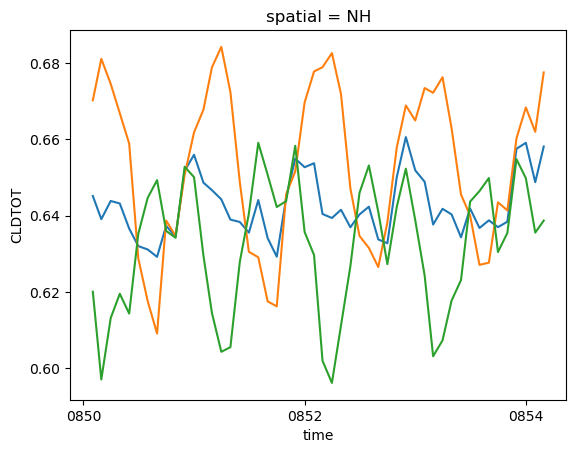

In [6]:
T_average.isel(time=slice(None,50)).plot()
T_average_SH.isel(time=slice(None,50)).plot()
T_average_NH.isel(time=slice(None,50)).plot()

In [29]:
xr.combine_by_coords([T_average, T_average_SH, T_average_NH])

<xarray.Dataset> Size: 444kB
Dimensions:  (spatial: 3, time: 13872)
Coordinates:
  * spatial  (spatial) <U2 24B 'G' 'NH' 'SH'
  * time     (time) object 111kB 0850-02-01 00:00:00 ... 2006-01-01 00:00:00
Data variables:
    CLDTOT   (spatial, time) float64 333kB dask.array<chunksize=(1, 1), meta=np.ndarray>

In [21]:
xr.merge([T_average, T_average_SH, T_average_NH])

ValueError: Could not find any dimension coordinates to use to order the Dataset objects for concatenation

For ARISE-SAI

In [ ]:
curc_lme_path = "/home/josh2250/kaydata/jshaw/RadInt/ARISE_SAI/d651059/ARISE-SAI-1.5/atm/proc/tseries/monthly/"
save_dir = "/projects/josh2250/PRISM/munged_data/CESM_LME/"

os.makedirs(save_dir, exist_ok=True)
# data_vars = ["FLNT", "FSNTOA"]
data_vars = ["CLDTOT", "FLNS", "FLNSC", "FLNT", "FLNTC", "FSNS", "FSNSC", "FSNTOA", "FSNTOAC", "LHFLX", "SHFLX",]
for var in data_vars:
    print(var)
    _path = Path(curc_lme_path).glob(var+"/*.nc")
    _file_paths = [str(i) for i in list(_path)]
    filename = Path(_file_paths[0]).stem
    _outpath = f"{save_dir}/{filename}.ANNavg.nc"
    if Path(_outpath).exists():
        print(f"Path for {var} exists, skipping.")
        continue
    mf_ds = xr.open_mfdataset(_file_paths, chunks={"time":1})
    T_average = mf_ds[var].mean(dim="lon").weighted(np.cos(np.deg2rad(mf_ds.lat))).mean(dim="lat")
    T_average.to_netcdf(_outpath)


In [12]:
Path(_outpath).exists

<bound method Path.exists of PosixPath('/projects/josh2250/PRISM/munged_data/b.e11.BLMTRC5CN.f19_g16.002.cam.h0.FSNTOA.085001-184912.ANNavg.nc')>

In [7]:
_outpath

'/projects/josh2250/PRISM/munged_data//b.e11.BLMTRC5CN.f19_g16.002.cam.h0.FSNTOA.085001-184912.ANNavg.nc'

In [10]:
import os
os.path.exists(_outpath)

False

In [42]:
Path(_file_paths[0]).stem

'b.e11.BLMTRC5CN.f19_g16.002.cam.h0.FLNT.085001-184912'

In [33]:
_file_paths = [str(i) for i in list(_path)]

In [39]:
list(_path)

[]

In [32]:
_path

<generator object Path.glob at 0x1519645d6df0>

In [29]:
mf_ds#["FLNT"]

<xarray.Dataset> Size: 815MB
Dimensions:       (time: 13872, lat: 96, lon: 144, ilev: 31, lev: 30, nbnd: 2,
                   slat: 95, slon: 144)
Coordinates:
  * time          (time) object 111kB 0850-02-01 00:00:00 ... 2006-01-01 00:0...
  * lat           (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon           (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * ilev          (ilev) float64 248B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * lev           (lev) float64 240B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * slat          (slat) float64 760B -89.05 -87.16 -85.26 ... 85.26 87.16 89.05
  * slon          (slon) float64 1kB -1.25 1.25 3.75 6.25 ... 351.2 353.8 356.2
Dimensions without coordinates: nbnd
Data variables: (12/32)
    FLNT          (time, lat, lon) float32 767MB dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
    P0            (time) float64 111kB 1e+05 1e+05 1e+05 ... 1e+05 1e+05 1e+05
    ch4vmr        (time) float64 111kB dask.array<chunksize=(1,), meta=np.ndarray>
    co2vmr        (time) float64 111kB dask.array<chunksize=(1,), meta=np.ndarray>
    date          (time) int32 55kB dask.array<chunksize=(1,), meta=np.ndarray>
    date_written  (time) |S8 111kB dask.array<chunksize=(1,), meta=np.ndarray>
    ...            ...
    ntrn          (time) int32 55kB 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1
    sol_tsi       (time) float64 111kB dask.array<chunksize=(1,), meta=np.ndarray>
    time_bnds     (time, nbnd) object 222kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_written  (time) |S8 111kB dask.array<chunksize=(1,), meta=np.ndarray>
    w_stag        (time, slat) float64 11MB dask.array<chunksize=(12000, 95), meta=np.ndarray>
    wnummax       (time, lat) int32 5MB dask.array<chunksize=(12000, 96), meta=np.ndarray>
Attributes: (12/13)
    Conventions:               CF-1.0
    source:                    CAM
    case:                      b.e11.BLMTRC5CN.f19_g16.002
    title:                     UNSET
    logname:                   mai
    host:                      ys0137
    ...                        ...
    revision_Id:               $Id$
    initial_file:              b.e11.B1850C5CN.f19_g16.0850cntl.001.cam.i.085...
    topography_file:           /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/...
    history:                   Tue Jan 28 04:57:41 2014: /glade/apps/opt/nco/...
    NCO:                       4.3.4
    nco_openmp_thread_number:  1

In [30]:
mf_ds["FLNT"].mean(dim="lon").weighted(np.cos(np.deg2rad(mf_ds.lat))).mean(dim="lat")

<xarray.DataArray 'FLNT' (time: 13872)> Size: 111kB
dask.array<truediv, shape=(13872,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 111kB 0850-02-01 00:00:00 ... 2006-01-01 00:00:00
Attributes:
    Sampling_Sequence:  rad_lwsw
    units:              W/m2
    long_name:          Net longwave flux at top of model
    cell_methods:       time: mean

In [15]:
test = Path(curc_lme_path)


In [16]:
list(_path)

[PosixPath('/home/josh2250/kaydata/jshaw/RadInt/CESM_LME/d651058/CESM-CAM5-LME/atm/proc/tseries/monthly/FSNTOA/b.e11.BLMTRC5CN.f19_g16.002.cam.h0.FSNTOA.085001-184912.nc'),
 PosixPath('/home/josh2250/kaydata/jshaw/RadInt/CESM_LME/d651058/CESM-CAM5-LME/atm/proc/tseries/monthly/FSNTOA/b.e11.BLMTRC5CN.f19_g16.002.cam.h0.FSNTOA.185001-200512.nc')]

In [21]:
[str(i) for i in list(_path)]

['/home/josh2250/kaydata/jshaw/RadInt/CESM_LME/d651058/CESM-CAM5-LME/atm/proc/tseries/monthly/FSNTOA/b.e11.BLMTRC5CN.f19_g16.002.cam.h0.FSNTOA.085001-184912.nc',
 '/home/josh2250/kaydata/jshaw/RadInt/CESM_LME/d651058/CESM-CAM5-LME/atm/proc/tseries/monthly/FSNTOA/b.e11.BLMTRC5CN.f19_g16.002.cam.h0.FSNTOA.185001-200512.nc']